<a href="https://www.kaggle.com/code/omborse771924/notebookbe73810637?scriptVersionId=344235779" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/costinflation/acetaminophen-prices-raw-dataset-2026/costinflation-acetaminophen-retail-prices-raw-2026-07-13-to-2026-08-10.csv


# EDA

In [2]:
df = pd.read_csv('/kaggle/input/datasets/costinflation/acetaminophen-prices-raw-dataset-2026/costinflation-acetaminophen-retail-prices-raw-2026-07-13-to-2026-08-10.csv')

In [3]:
df.head()

,series_id,series_title,canonical_url,geography_type,geography_id,geography_label,observed_date,product_name,quantity_value,quantity_unit,quantity_name,price_amount,currency_code,normalized_price_amount,normalized_quantity_value,normalized_quantity_unit
0,acetaminophen,Acetaminophen,https://costinflation.com/indices/acetaminophe...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,Acetaminophen 325mg 20 Softgels for Pain Relie...,20,units,20 units,7.99,USD,39.9500,100,units
1,acetaminophen,Acetaminophen,https://costinflation.com/indices/acetaminophe...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,"Acetaminophen 500mg, Extra Strength Rapid Rele...",0,unknown,unknown,29.99,USD,NaN,100,units
2,acetaminophen,Acetaminophen,https://costinflation.com/indices/acetaminophe...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,"Acetaminophen Extended-Release Tablets, 650 mg...",100,units,100 units,8.99,USD,8.9900,100,units
3,acetaminophen,Acetaminophen,https://costinflation.com/indices/acetaminophe...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,Amazon Basic Care Acetaminophen Extended-Relea...,100,units,100 units,8.23,USD,8.2300,100,units
4,acetaminophen,Acetaminophen,https://costinflation.com/indices/acetaminophe...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,Amazon Basic Care Acetaminophen Extended-Relea...,400,units,400 units,21.59,USD,5.3975,100,units


In [4]:
df.columns

Index(['series_id', 'series_title', 'canonical_url', 'geography_type',
       'geography_id', 'geography_label', 'observed_date', 'product_name',
       'quantity_value', 'quantity_unit', 'quantity_name', 'price_amount',
       'currency_code', 'normalized_price_amount', 'normalized_quantity_value',
       'normalized_quantity_unit'],
      dtype='object')

DATASET LOADED SUCCESSFULLY
Shape: (11116, 16)

Columns:
['series_id', 'series_title', 'canonical_url', 'geography_type', 'geography_id', 'geography_label', 'observed_date', 'product_name', 'quantity_value', 'quantity_unit', 'quantity_name', 'price_amount', 'currency_code', 'normalized_price_amount', 'normalized_quantity_value', 'normalized_quantity_unit']

COLUMN VALIDATION
All expected columns are present.

BASIC DATASET INFORMATION
Rows: 11116
Columns: 16
Memory usage:
9.208742141723633 MB

Data Types:
series_id                     object
series_title                  object
canonical_url                 object
geography_type                object
geography_id                   int64
geography_label               object
observed_date                 object
product_name                  object
quantity_value                 int64
quantity_unit                 object
quantity_name                 object
price_amount                 float64
currency_code                 object
normaliz

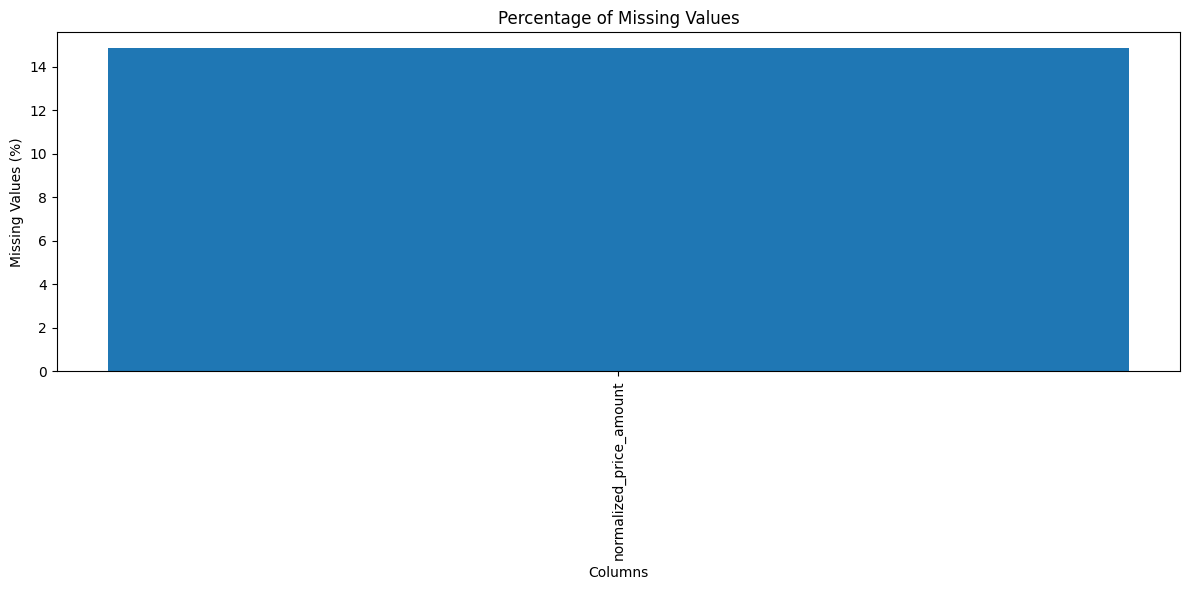


DUPLICATE ANALYSIS
Complete duplicate rows: 0
Duplicate percentage: 0.0 %

--------------------------------------------------
DUPLICATE CHECK: series_id
--------------------------------------------------
Duplicated values: 11115
Unique values: 1

--------------------------------------------------
DUPLICATE CHECK: canonical_url
--------------------------------------------------
Duplicated values: 11115
Unique values: 1

UNIQUE VALUE ANALYSIS
                           Unique_Count  Unique_Percentage
price_amount                        139               1.25
normalized_price_amount             121               1.09
product_name                         63               0.57
observed_date                        29               0.26
quantity_value                       16               0.14
quantity_name                        16               0.14
geography_id                         12               0.11
geography_label                      12               0.11
quantity_unit          

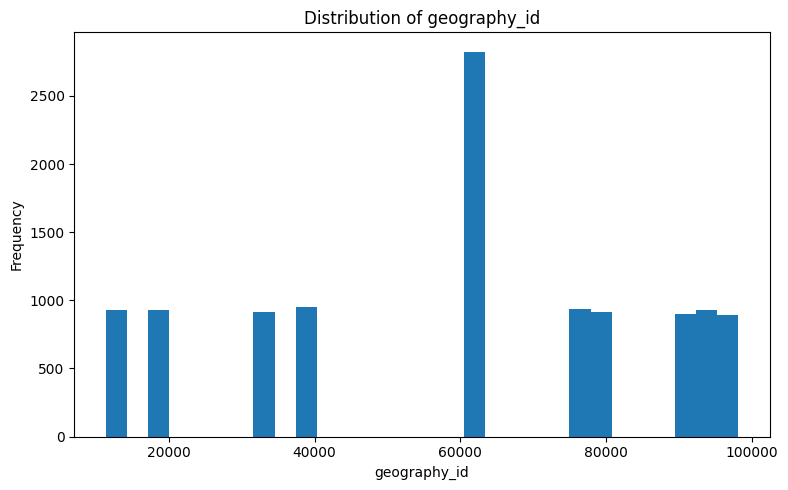

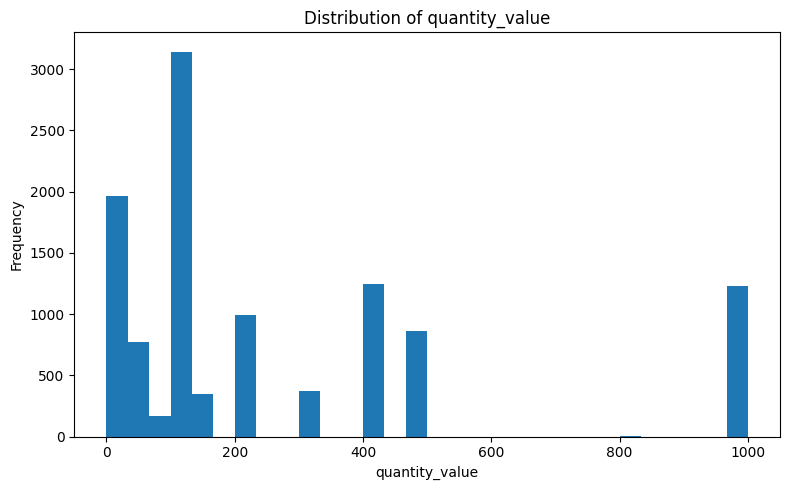

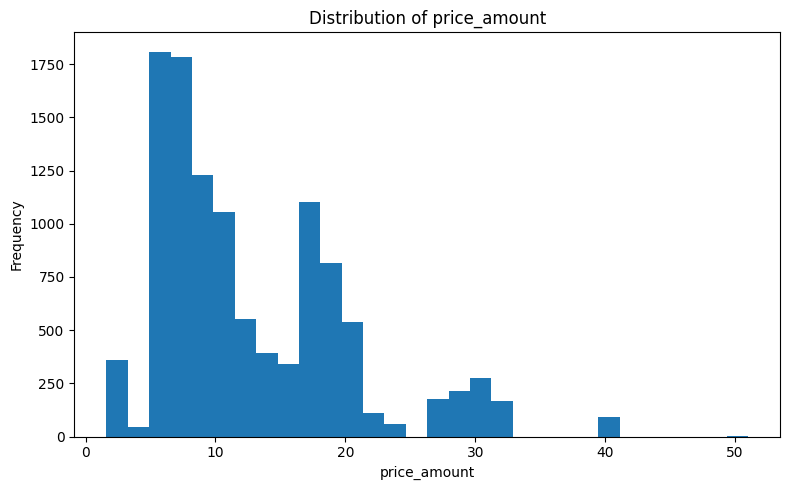

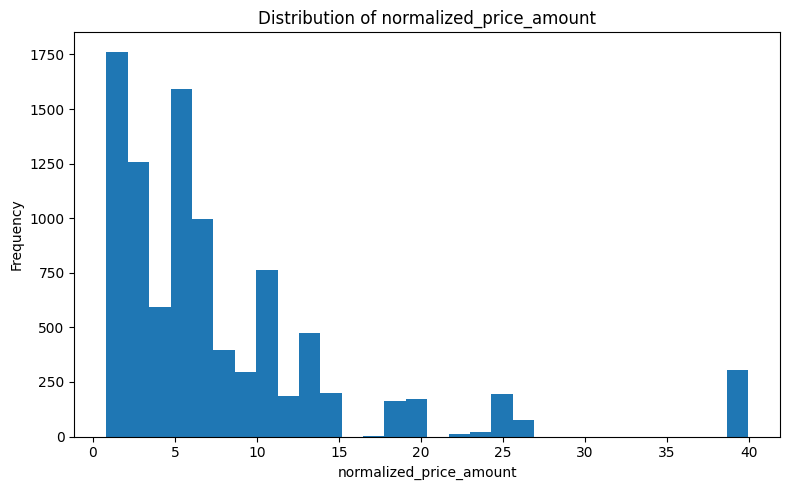

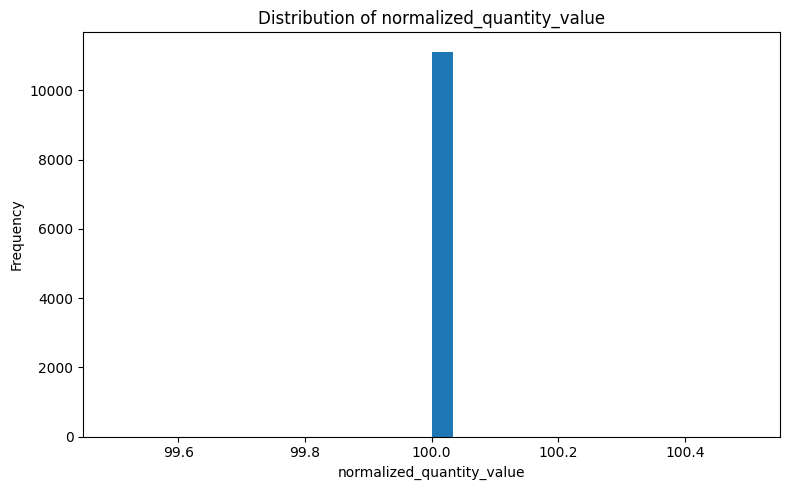

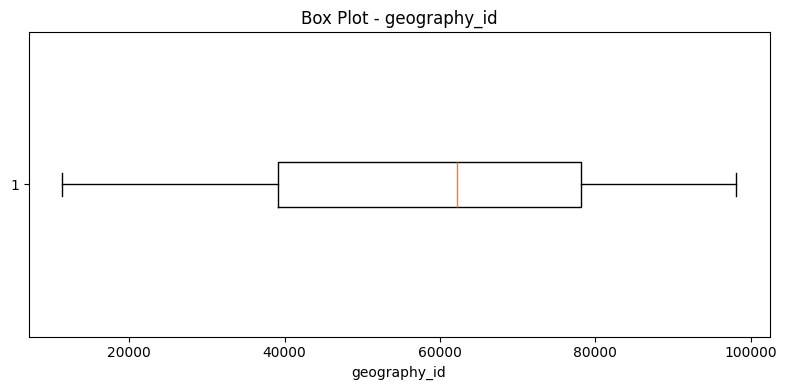

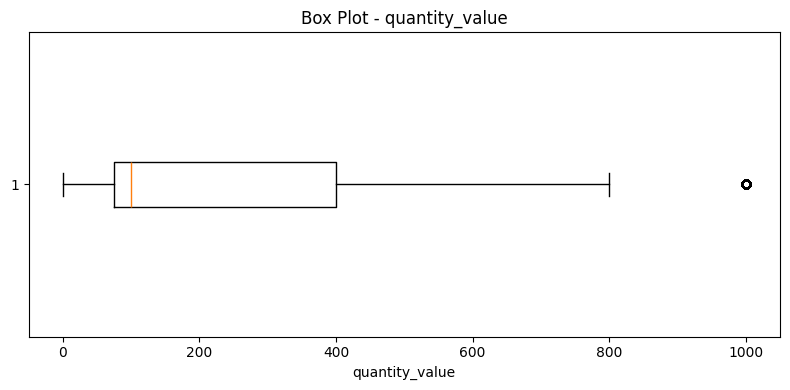

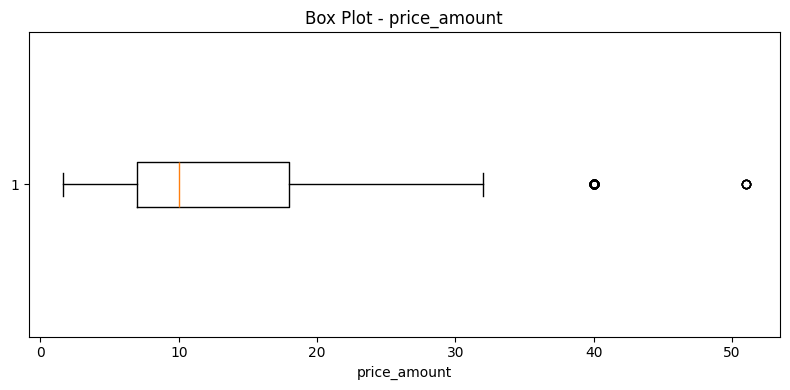

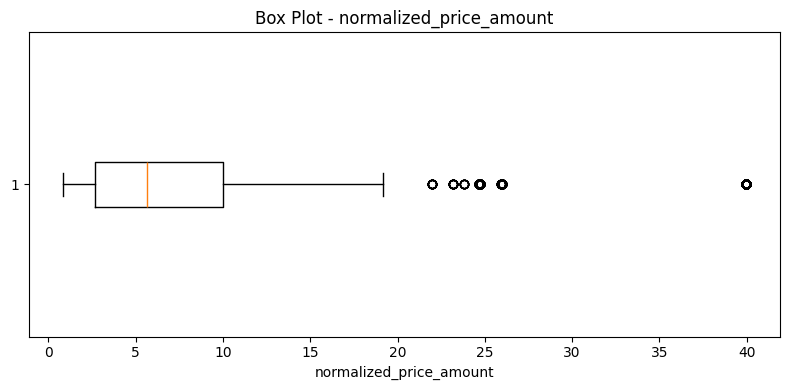

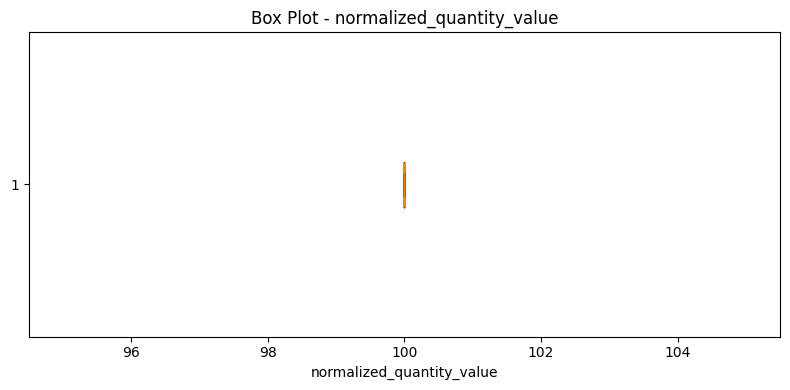


OUTLIER ANALYSIS USING IQR
                      Column         Q1        Q3        IQR  Lower_Bound  \
0               geography_id  39206.000  78228.00  39022.000  -19327.0000   
1             quantity_value     75.000    400.00    325.000    -412.5000   
2               price_amount      6.990     17.99     11.000      -9.5100   
3    normalized_price_amount      2.685      9.99      7.305      -8.2725   
4  normalized_quantity_value    100.000    100.00      0.000     100.0000   

   Upper_Bound  Outlier_Count  Outlier_Percentage  
0  136761.0000              0                0.00  
1     887.5000           1232               11.08  
2      34.4900             99                0.89  
3      20.9475            612                5.51  
4     100.0000              0                0.00  

DATE ANALYSIS
Minimum date:
2026-07-13 00:00:00

Maximum date:
2026-08-10 00:00:00

Invalid dates:
0

Records by year:
year
2026    11116
Name: count, dtype: int64


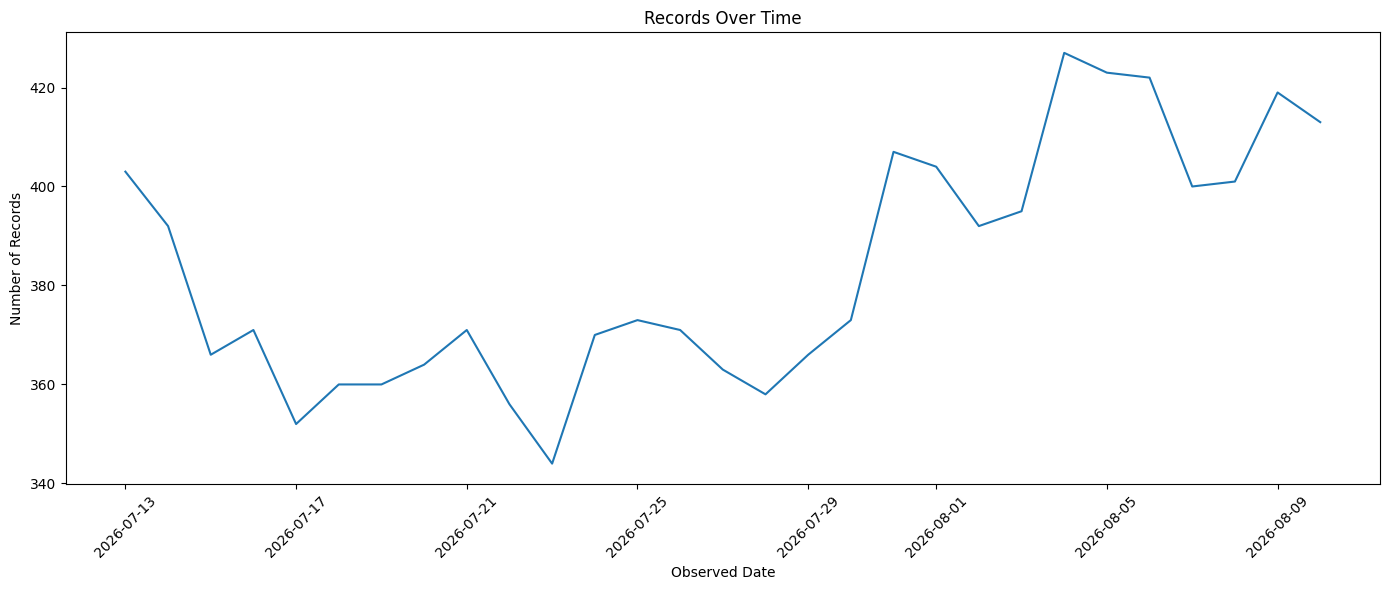


CURRENCY ANALYSIS
currency_code
USD    11116
Name: count, dtype: int64


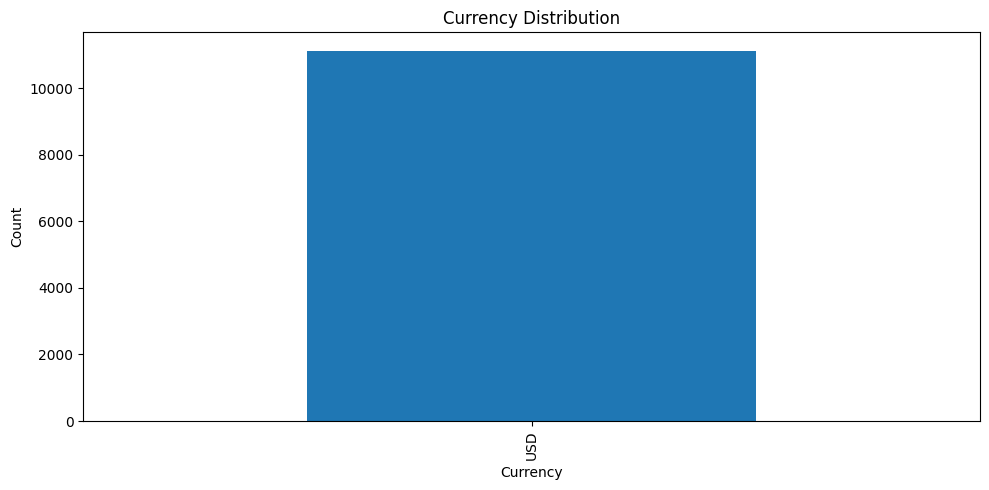


GEOGRAPHY ANALYSIS
geography_type
postal_code    11116
Name: count, dtype: int64

Top 20 Geographies:
geography_label
Jackson, MS - North Jackson              948
East St. Louis, IL                       944
Clayton, MO                              944
Chicago, IL - North Center/Avondale      938
Houston, TX - Midtown                    935
Philadelphia, PA - South Philadelphia    928
San Jose, CA - Blossom Valley            927
New York, NY - Ridgewood/Glendale        927
San Antonio, TX - West San Antonio       916
Jacksonville, FL - Westside              915
Los Angeles, CA - Mid-City               898
Seattle, WA - Rainier Valley             896
Name: count, dtype: int64

PRODUCT ANALYSIS
Unique products: 63

Top 20 products:
product_name
Acetaminophen 500mg, Extra Strength Rapid Release, 400 Gelcaps                                                                                                                                             441
Amazon Basic Care Extra Strength Acetam

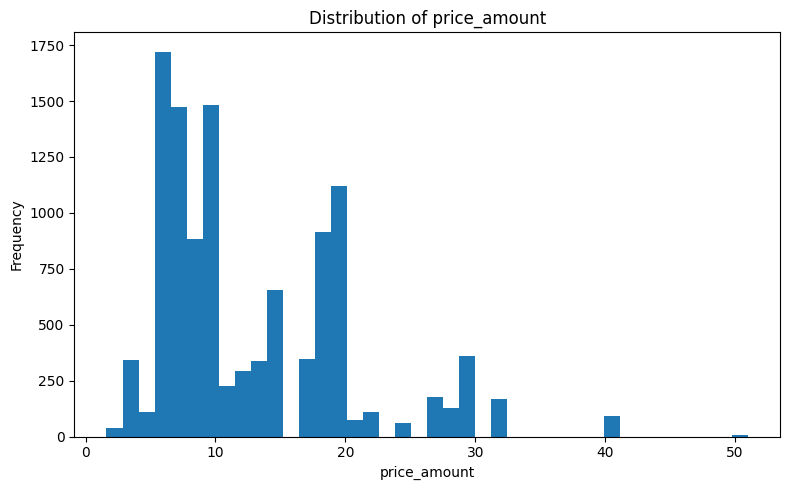

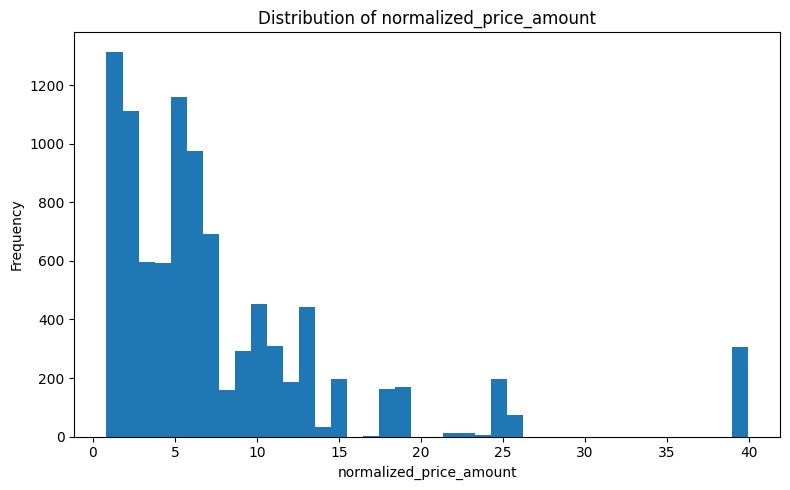

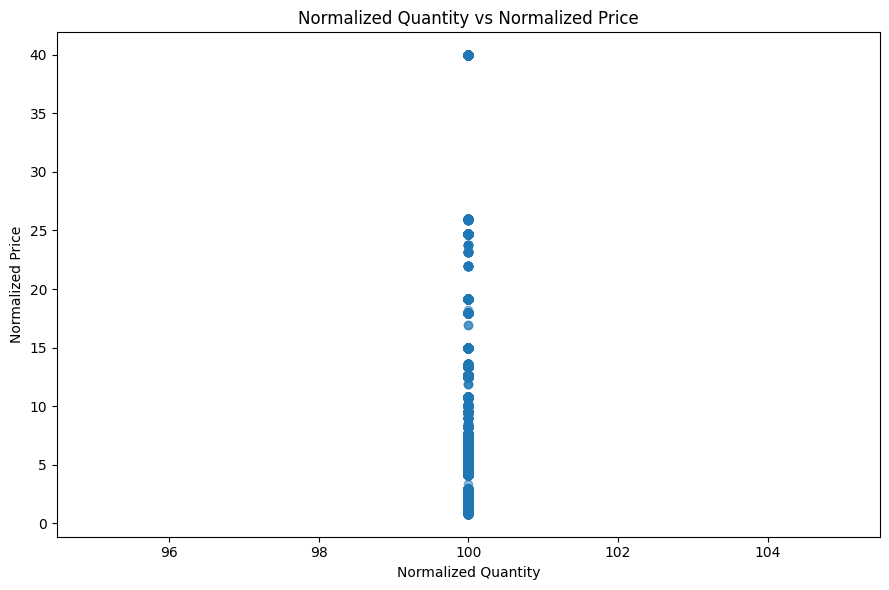


CORRELATION MATRIX
                           geography_id  quantity_value  price_amount  \
geography_id                   1.000000       -0.000252     -0.000194   
quantity_value                -0.000252        1.000000      0.285218   
price_amount                  -0.000194        0.285218      1.000000   
normalized_price_amount       -0.003916       -0.511994     -0.048116   
normalized_quantity_value           NaN             NaN           NaN   
year                                NaN             NaN           NaN   
month                          0.004364        0.053506      0.024720   
day                           -0.001160       -0.040672     -0.014996   

                           normalized_price_amount  normalized_quantity_value  \
geography_id                             -0.003916                        NaN   
quantity_value                           -0.511994                        NaN   
price_amount                             -0.048116                        NaN  

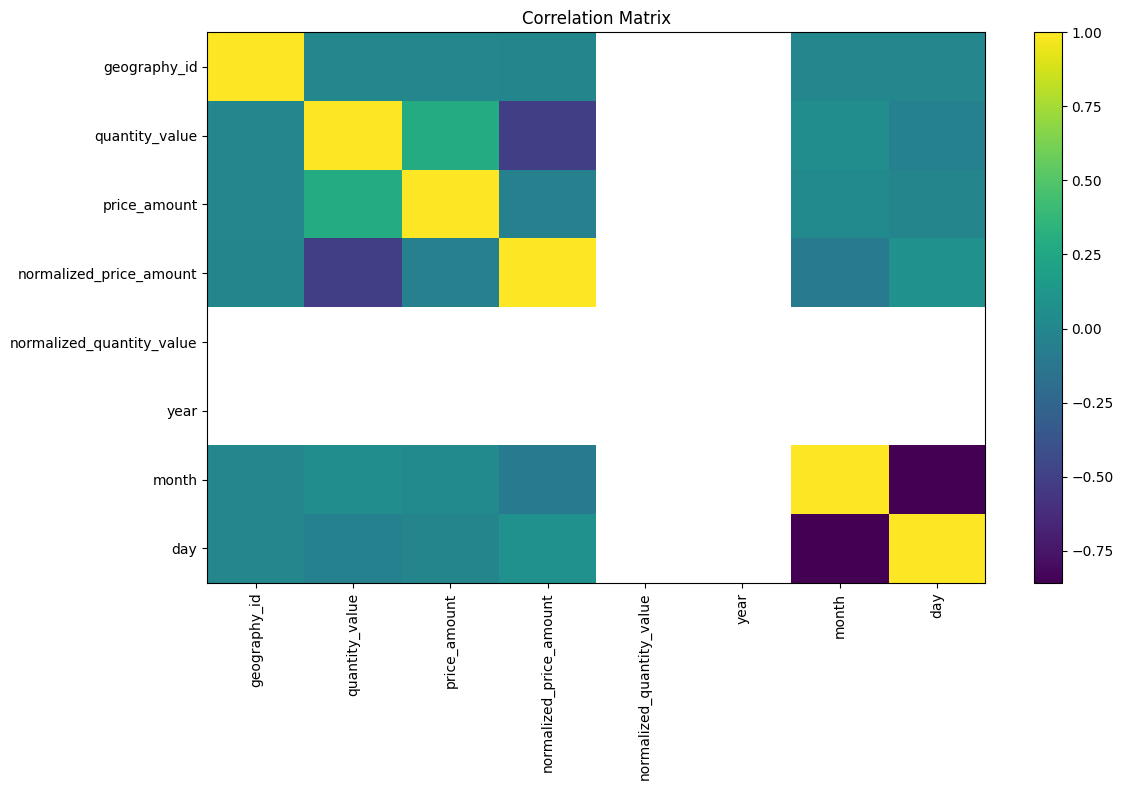


DATA QUALITY CHECKS
Negative price_amount: 0
Negative normalized_price_amount: 0
Negative quantity_value: 0
Negative normalized_quantity_value: 0

REMOVING COMPLETE DUPLICATES
Rows before: 11116
Rows after: 11116
Duplicates removed: 0

HANDLING NULL VALUES
normalized_price_amount: filled missing values with median = 5.66

FINAL NULL CHECK
series_id                    0
series_title                 0
canonical_url                0
geography_type               0
geography_id                 0
geography_label              0
observed_date                0
product_name                 0
quantity_value               0
quantity_unit                0
quantity_name                0
price_amount                 0
currency_code                0
normalized_price_amount      0
normalized_quantity_value    0
normalized_quantity_unit     0
year                         0
month                        0
day                          0
dtype: int64

Total remaining null values: 0

FINAL DUPLICATE CHECK
R

In [5]:
# ============================================================
# COMPLETE EDA + NULL HANDLING + DUPLICATE HANDLING
# ============================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder


# ============================================================
# 2. LOAD DATASET
# ============================================================

print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 3. DEFINE EXPECTED COLUMNS
# ============================================================

expected_columns = [
    'series_id',
    'series_title',
    'canonical_url',
    'geography_type',
    'geography_id',
    'geography_label',
    'observed_date',
    'product_name',
    'quantity_value',
    'quantity_unit',
    'quantity_name',
    'price_amount',
    'currency_code',
    'normalized_price_amount',
    'normalized_quantity_value',
    'normalized_quantity_unit'
]

print("\n" + "=" * 70)
print("COLUMN VALIDATION")
print("=" * 70)

missing_columns = [
    col for col in expected_columns
    if col not in df.columns
]

extra_columns = [
    col for col in df.columns
    if col not in expected_columns
]

if missing_columns:
    print("Missing expected columns:", missing_columns)
else:
    print("All expected columns are present.")

if extra_columns:
    print("Additional columns:", extra_columns)


# ============================================================
# 4. BASIC DATASET INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("BASIC DATASET INFORMATION")
print("=" * 70)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Memory usage:")
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()


# ============================================================
# 5. FIRST 5 ROWS
# ============================================================

print("\n" + "=" * 70)
print("FIRST 5 ROWS")
print("=" * 70)

print(df.head())


# ============================================================
# 6. LAST 5 ROWS
# ============================================================

print("\n" + "=" * 70)
print("LAST 5 ROWS")
print("=" * 70)

print(df.tail())


# ============================================================
# 7. STATISTICAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("NUMERICAL STATISTICS")
print("=" * 70)

print(df.describe(include='all').T)


# ============================================================
# 8. NULL VALUE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("NULL VALUE ANALYSIS")
print("=" * 70)

null_count = df.isnull().sum()

null_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

null_summary = pd.DataFrame({
    'Null_Count': null_count,
    'Null_Percentage': null_percentage
})

null_summary = null_summary.sort_values(
    by='Null_Percentage',
    ascending=False
)

print(null_summary)


# ============================================================
# 9. VISUALIZE NULL VALUES
# ============================================================

null_plot = null_summary[
    null_summary['Null_Count'] > 0
]

if len(null_plot) > 0:

    plt.figure(figsize=(12, 6))

    plt.bar(
        null_plot.index,
        null_plot['Null_Percentage']
    )

    plt.xticks(
        rotation=90
    )

    plt.ylabel("Missing Values (%)")
    plt.xlabel("Columns")
    plt.title("Percentage of Missing Values")

    plt.tight_layout()
    plt.show()

else:
    print("\nNo missing values found.")


# ============================================================
# 10. DUPLICATE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("DUPLICATE ANALYSIS")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print("Complete duplicate rows:", duplicate_count)

print(
    "Duplicate percentage:",
    round(duplicate_count / len(df) * 100, 2),
    "%"
)


# ============================================================
# 11. CHECK DUPLICATES BY IMPORTANT IDENTIFIERS
# ============================================================

identifier_columns = [
    'series_id',
    'canonical_url'
]

for col in identifier_columns:

    if col in df.columns:

        print("\n" + "-" * 50)
        print(f"DUPLICATE CHECK: {col}")
        print("-" * 50)

        print(
            "Duplicated values:",
            df[col].duplicated().sum()
        )

        print(
            "Unique values:",
            df[col].nunique(dropna=True)
        )


# ============================================================
# 12. UNIQUE VALUE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("UNIQUE VALUE ANALYSIS")
print("=" * 70)

unique_summary = pd.DataFrame({
    'Unique_Count': df.nunique(),
    'Unique_Percentage':
        (df.nunique() / len(df) * 100).round(2)
})

print(unique_summary.sort_values(
    by='Unique_Count',
    ascending=False
))


# ============================================================
# 13. CATEGORICAL COLUMN ANALYSIS
# ============================================================

categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns

print("\n" + "=" * 70)
print("CATEGORICAL COLUMN ANALYSIS")
print("=" * 70)

for col in categorical_columns:

    print("\n" + "-" * 60)
    print(f"Column: {col}")
    print("-" * 60)

    print("Unique values:", df[col].nunique())

    print("\nTop 10 values:")
    print(df[col].value_counts(
        dropna=False
    ).head(10))


# ============================================================
# 14. NUMERICAL COLUMN ANALYSIS
# ============================================================

numerical_columns = df.select_dtypes(
    include=np.number
).columns

print("\n" + "=" * 70)
print("NUMERICAL COLUMN ANALYSIS")
print("=" * 70)

print(
    df[numerical_columns].describe().T
)


# ============================================================
# 15. NUMERICAL DISTRIBUTIONS
# ============================================================

for col in numerical_columns:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[col].dropna(),
        bins=30
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")

    plt.tight_layout()
    plt.show()


# ============================================================
# 16. BOX PLOTS FOR OUTLIER DETECTION
# ============================================================

for col in numerical_columns:

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        df[col].dropna(),
        vert=False
    )

    plt.xlabel(col)
    plt.title(f"Box Plot - {col}")

    plt.tight_layout()
    plt.show()


# ============================================================
# 17. IQR OUTLIER ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("OUTLIER ANALYSIS USING IQR")
print("=" * 70)

outlier_summary = []

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_count = len(outliers)

    outlier_percentage = (
        outlier_count / len(df) * 100
    )

    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outlier_count,
        'Outlier_Percentage':
            round(outlier_percentage, 2)
    })

outlier_df = pd.DataFrame(
    outlier_summary
)

print(outlier_df)


# ============================================================
# 18. DATE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("DATE ANALYSIS")
print("=" * 70)

if 'observed_date' in df.columns:

    df['observed_date'] = pd.to_datetime(
        df['observed_date'],
        errors='coerce'
    )

    print("Minimum date:")
    print(df['observed_date'].min())

    print("\nMaximum date:")
    print(df['observed_date'].max())

    print("\nInvalid dates:")
    print(df['observed_date'].isna().sum())

    # Extract date components
    df['year'] = df['observed_date'].dt.year
    df['month'] = df['observed_date'].dt.month
    df['day'] = df['observed_date'].dt.day

    print("\nRecords by year:")
    print(df['year'].value_counts().sort_index())


# ============================================================
# 19. RECORDS OVER TIME
# ============================================================

if 'observed_date' in df.columns:

    date_counts = (
        df.groupby('observed_date')
        .size()
        .sort_index()
    )

    plt.figure(figsize=(14, 6))

    plt.plot(
        date_counts.index,
        date_counts.values
    )

    plt.xlabel("Observed Date")
    plt.ylabel("Number of Records")
    plt.title("Records Over Time")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 20. CURRENCY ANALYSIS
# ============================================================

if 'currency_code' in df.columns:

    print("\n" + "=" * 70)
    print("CURRENCY ANALYSIS")
    print("=" * 70)

    print(
        df['currency_code']
        .value_counts(dropna=False)
    )

    plt.figure(figsize=(10, 5))

    df['currency_code'].value_counts(
        dropna=False
    ).head(15).plot(
        kind='bar'
    )

    plt.xlabel("Currency")
    plt.ylabel("Count")
    plt.title("Currency Distribution")

    plt.tight_layout()
    plt.show()


# ============================================================
# 21. GEOGRAPHY ANALYSIS
# ============================================================

if 'geography_type' in df.columns:

    print("\n" + "=" * 70)
    print("GEOGRAPHY ANALYSIS")
    print("=" * 70)

    print(
        df['geography_type']
        .value_counts(dropna=False)
    )

if 'geography_label' in df.columns:

    print("\nTop 20 Geographies:")

    print(
        df['geography_label']
        .value_counts(dropna=False)
        .head(20)
    )


# ============================================================
# 22. PRODUCT ANALYSIS
# ============================================================

if 'product_name' in df.columns:

    print("\n" + "=" * 70)
    print("PRODUCT ANALYSIS")
    print("=" * 70)

    print(
        "Unique products:",
        df['product_name'].nunique()
    )

    print("\nTop 20 products:")

    print(
        df['product_name']
        .value_counts(dropna=False)
        .head(20)
    )


# ============================================================
# 23. QUANTITY ANALYSIS
# ============================================================

quantity_columns = [
    'quantity_value',
    'normalized_quantity_value'
]

for col in quantity_columns:

    if col in df.columns:

        print("\n" + "=" * 70)
        print(f"QUANTITY ANALYSIS: {col}")
        print("=" * 70)

        print(
            df[col].describe()
        )

        print("\nNegative values:")
        print(
            (df[col] < 0).sum()
        )

        print("\nZero values:")
        print(
            (df[col] == 0).sum()
        )


# ============================================================
# 24. PRICE ANALYSIS
# ============================================================

price_columns = [
    'price_amount',
    'normalized_price_amount'
]

for col in price_columns:

    if col in df.columns:

        print("\n" + "=" * 70)
        print(f"PRICE ANALYSIS: {col}")
        print("=" * 70)

        print(
            df[col].describe()
        )

        print("\nNegative values:")
        print(
            (df[col] < 0).sum()
        )

        print("\nZero values:")
        print(
            (df[col] == 0).sum()
        )


# ============================================================
# 25. PRICE DISTRIBUTION
# ============================================================

for col in price_columns:

    if col in df.columns:

        plt.figure(figsize=(8, 5))

        plt.hist(
            df[col].dropna(),
            bins=40
        )

        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.title(f"Distribution of {col}")

        plt.tight_layout()
        plt.show()


# ============================================================
# 26. QUANTITY VS PRICE
# ============================================================

if (
    'normalized_quantity_value' in df.columns
    and
    'normalized_price_amount' in df.columns
):

    plt.figure(figsize=(9, 6))

    plt.scatter(
        df['normalized_quantity_value'],
        df['normalized_price_amount'],
        alpha=0.5
    )

    plt.xlabel("Normalized Quantity")
    plt.ylabel("Normalized Price")
    plt.title(
        "Normalized Quantity vs Normalized Price"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 27. CORRELATION ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)

numeric_df = df.select_dtypes(
    include=np.number
)

correlation = numeric_df.corr()

print(correlation)


# ============================================================
# 28. CORRELATION HEATMAP
# ============================================================

if not correlation.empty:

    plt.figure(figsize=(12, 8))

    plt.imshow(
        correlation,
        aspect='auto'
    )

    plt.colorbar()

    plt.xticks(
        range(len(correlation.columns)),
        correlation.columns,
        rotation=90
    )

    plt.yticks(
        range(len(correlation.columns)),
        correlation.columns
    )

    plt.title("Correlation Matrix")

    plt.tight_layout()
    plt.show()


# ============================================================
# 29. DATA QUALITY CHECKS
# ============================================================

print("\n" + "=" * 70)
print("DATA QUALITY CHECKS")
print("=" * 70)


# Negative prices
if 'price_amount' in df.columns:

    print(
        "Negative price_amount:",
        (df['price_amount'] < 0).sum()
    )


# Negative normalized prices
if 'normalized_price_amount' in df.columns:

    print(
        "Negative normalized_price_amount:",
        (df['normalized_price_amount'] < 0).sum()
    )


# Negative quantities
if 'quantity_value' in df.columns:

    print(
        "Negative quantity_value:",
        (df['quantity_value'] < 0).sum()
    )


# Negative normalized quantities
if 'normalized_quantity_value' in df.columns:

    print(
        "Negative normalized_quantity_value:",
        (df['normalized_quantity_value'] < 0).sum()
    )


# ============================================================
# 30. HANDLE DUPLICATES
# ============================================================

print("\n" + "=" * 70)
print("REMOVING COMPLETE DUPLICATES")
print("=" * 70)

before_duplicates = len(df)

df = df.drop_duplicates()

after_duplicates = len(df)

print(
    "Rows before:",
    before_duplicates
)

print(
    "Rows after:",
    after_duplicates
)

print(
    "Duplicates removed:",
    before_duplicates - after_duplicates
)


# ============================================================
# 31. HANDLE NULL VALUES
# ============================================================

print("\n" + "=" * 70)
print("HANDLING NULL VALUES")
print("=" * 70)


# ------------------------------------------------------------
# NUMERICAL COLUMNS
# Use median because it is more robust to outliers
# ------------------------------------------------------------

numeric_columns = df.select_dtypes(
    include=np.number
).columns

for col in numeric_columns:

    if df[col].isnull().sum() > 0:

        median_value = df[col].median()

        df[col] = df[col].fillna(
            median_value
        )

        print(
            f"{col}: filled missing values "
            f"with median = {median_value}"
        )


# ------------------------------------------------------------
# CATEGORICAL COLUMNS
# Use mode
# ------------------------------------------------------------

categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns

for col in categorical_columns:

    if df[col].isnull().sum() > 0:

        mode_values = df[col].mode()

        if len(mode_values) > 0:

            mode_value = mode_values[0]

            df[col] = df[col].fillna(
                mode_value
            )

            print(
                f"{col}: filled missing values "
                f"with mode = {mode_value}"
            )


# ============================================================
# 32. FINAL NULL CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL NULL CHECK")
print("=" * 70)

final_nulls = df.isnull().sum()

print(final_nulls)

print(
    "\nTotal remaining null values:",
    final_nulls.sum()
)


# ============================================================
# 33. FINAL DUPLICATE CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL DUPLICATE CHECK")
print("=" * 70)

print(
    "Remaining duplicate rows:",
    df.duplicated().sum()
)


# ============================================================
# 34. FINAL DATASET INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL CLEAN DATASET")
print("=" * 70)

print("Final shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 35. FINAL STATISTICAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL STATISTICAL SUMMARY")
print("=" * 70)

print(
    df.describe(include='all').T
)


# ============================================================
# 36. SAVE CLEAN DATASET
# ============================================================

OUTPUT_FILE = "cleaned_dataset.csv"

df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\n" + "=" * 70)
print("CLEAN DATASET SAVED")
print("=" * 70)

print(
    f"File saved as: {OUTPUT_FILE}"
)


# ============================================================
# 37. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("EDA SUMMARY")
print("=" * 70)

print("Original rows:", before_duplicates)
print("Final rows:", len(df))

print(
    "Duplicate rows removed:",
    before_duplicates - after_duplicates
)

print(
    "Remaining null values:",
    df.isnull().sum().sum()
)

print(
    "Remaining duplicate rows:",
    df.duplicated().sum()
)

print(
    "Final number of columns:",
    df.shape[1]
)

print("\nEDA + DATA CLEANING COMPLETED SUCCESSFULLY! 🚀")